In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

# ---------- Helper: load Spark "directory CSV" ----------
def load_spark_single_csv(dir_path: Path) -> pd.DataFrame:
    """
    Spark wrote each dataset as a folder with one part-*.csv.
    This picks that one CSV file and loads it.
    """
    if not dir_path.exists():
        raise FileNotFoundError(f"Directory not found: {dir_path}")

    csv_files = [p for p in dir_path.glob("*.csv") if not p.name.startswith("_")]
    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in {dir_path}")

    return pd.read_csv(csv_files[0])


def normalize_column(df: pd.DataFrame, col: str, new_col: str) -> None:
    """Min–max normalize df[col] into [0, 1] and store in df[new_col]."""
    if col not in df.columns:
        df[new_col] = 0.0
        return

    col_min = df[col].min()
    col_max = df[col].max()

    if pd.isna(col_min) or pd.isna(col_max) or col_min == col_max:
        df[new_col] = 0.0
    else:
        df[new_col] = (df[col] - col_min) / (col_max - col_min)


# ---------- Paths ----------
project_root = Path("..").resolve()
print("Project root:", project_root)

sample_history_path = project_root / "data_processed" / "sample" / "user_listening_history_sample.csv"
full_history_path   = project_root / "data_processed" / "graph_for_spark" / "listened_edges.csv"

# Prefer sample history for faster evaluation
if sample_history_path.exists():
    history_path = sample_history_path
    print("Using SAMPLE history:", history_path)
else:
    history_path = full_history_path
    print("Using FULL history:", history_path)

songs_path = project_root / "data_processed" / "graph_for_spark" / "songs.csv"

spark_out_dir = project_root / "data_processed" / "spark_outputs"
pop_dir   = spark_out_dir / "song_popularity_top1000.csv"
pr_dir    = spark_out_dir / "song_pagerank_top1000.csv"
pairs_dir = spark_out_dir / "song_co_listen_pairs_top1000.csv"

# ---------- Load data ----------
history_df = pd.read_csv(history_path)
songs_df   = pd.read_csv(songs_path)

popularity_df = load_spark_single_csv(pop_dir)
pagerank_df   = load_spark_single_csv(pr_dir)
pairs_df      = load_spark_single_csv(pairs_dir)

print("History shape:", history_df.shape)
print("Songs shape:", songs_df.shape)
print("Popularity shape:", popularity_df.shape)
print("Pagerank shape:", pagerank_df.shape)
print("Pairs shape:", pairs_df.shape)

# Ensure consistent types
history_df["track_id"] = history_df["track_id"].astype(str)
history_df["user_id"]  = history_df["user_id"].astype(str)

songs_df["track_id"]       = songs_df["track_id"].astype(str)
popularity_df["track_id"]  = popularity_df["track_id"].astype(str)
pagerank_df["track_id"]    = pagerank_df["track_id"].astype(str)
pairs_df["track_id_1"]     = pairs_df["track_id_1"].astype(str)
pairs_df["track_id_2"]     = pairs_df["track_id_2"].astype(str)

Project root: /Users/shritej/graph-music-recs
Using SAMPLE history: /Users/shritej/graph-music-recs/data_processed/sample/user_listening_history_sample.csv
History shape: (49172, 3)
Songs shape: (30459, 21)
Popularity shape: (1000, 23)
Pagerank shape: (1000, 22)
Pairs shape: (1000, 3)


In [2]:
def recommend_from_seed_tracks(seed_tracks, top_k=20):
    """
    Given a set/list of seed tracks (user's train items),
    build candidate songs using co-listen pairs + popularity + PageRank.
    Returns a DataFrame of top-K recommendations.
    """
    seed_tracks = set(seed_tracks)
    if not seed_tracks:
        return None

    # Keep only co-listen pairs where either side is in the seed set
    mask = pairs_df["track_id_1"].isin(seed_tracks) | pairs_df["track_id_2"].isin(seed_tracks)
    pairs_user = pairs_df[mask].copy()

    if pairs_user.empty:
        return None

    # Determine the candidate track in each pair (the "other" song)
    def candidate_from_row(row):
        if row["track_id_1"] in seed_tracks:
            return row["track_id_2"]
        else:
            return row["track_id_1"]

    pairs_user["track_id"] = pairs_user.apply(candidate_from_row, axis=1)

    # Aggregate co-listen counts per candidate track
    cf_scores = (
        pairs_user.groupby("track_id")["co_listen_count"]
        .sum()
        .reset_index()
        .rename(columns={"co_listen_count": "cf_score"})
    )

    # Merge with popularity & PageRank
    merged = cf_scores.merge(
        popularity_df[["track_id", "total_playcount"]], on="track_id", how="left"
    ).merge(
        pagerank_df[["track_id", "pagerank"]], on="track_id", how="left"
    )

    # Fill missing numeric values
    for col in ["cf_score", "total_playcount", "pagerank"]:
        if col in merged.columns:
            merged[col] = merged[col].fillna(0)

    # Normalize each signal
    normalize_column(merged, "cf_score",       "cf_norm")
    normalize_column(merged, "total_playcount","pop_norm")
    normalize_column(merged, "pagerank",       "pr_norm")

    # Weighted final score (you can mention these weights in the paper)
    merged["final_score"] = (
        0.5 * merged["cf_norm"] +
        0.3 * merged["pop_norm"] +
        0.2 * merged["pr_norm"]
    )

    # Don't recommend songs the user already listened to in train
    merged = merged[~merged["track_id"].isin(seed_tracks)]

    if merged.empty:
        return None

    # Join with song metadata
    songs_meta = songs_df[["track_id", "name", "artist", "genre", "year"]].copy()
    final_recs = merged.merge(songs_meta, on="track_id", how="left")

    final_recs = final_recs.sort_values("final_score", ascending=False)
    final_recs = final_recs.head(top_k).reset_index(drop=True)

    return final_recs


# Quick smoke test with one random user
one_user = history_df["user_id"].value_counts().index[0]
tracks_for_user = history_df[history_df["user_id"] == one_user]["track_id"].unique().tolist()
print("Test user:", one_user, "num tracks:", len(tracks_for_user))

test_recs = recommend_from_seed_tracks(tracks_for_user[:5], top_k=5)
print(test_recs.head())


Test user: db6a78c78c9239aba33861dae7611a6893fb27d5 num tracks: 211
             track_id  cf_score  total_playcount    pagerank   cf_norm  \
0  TRONYHY128F92C9D11      7252           527893  367.746229  0.881234   
1  TRUFTBY128F93450B8      8026           111615  175.147208  1.000000   
2  TRXWAZC128F9314B3E      6619            87745  152.400912  0.784103   
3  TRPGPDK12903CCC651      5886            91448  116.056197  0.671628   
4  TRWAQOC12903CB84CA      5949            72259  117.249041  0.681295   

   pop_norm   pr_norm  final_score                name             artist  \
0  1.000000  1.000000     0.940617             Revelry      Kings of Leon   
1  0.196143  0.433082     0.645459           Alejandro          Lady Gaga   
2  0.150049  0.366128     0.510292  Heartbreak Warfare         John Mayer   
3  0.157200  0.259147     0.434803    Bring Me To Life  Katherine Jenkins   
4  0.120145  0.262658     0.429223          Sexy Bitch       David Guetta   

  genre  year  
0  Rock 

In [3]:
# Group user → list of tracks
user_items = history_df.groupby("user_id")["track_id"].apply(list)

# Keep users with at least 5 interactions
min_items = 5
eligible = user_items[user_items.apply(len) >= min_items]
print("Number of eligible users (>=5 tracks):", len(eligible))

# We'll evaluate on first 50 eligible users for speed
np.random.seed(42)
eval_users = eligible.head(50)

eval_data = []
for user_id, items in eval_users.items():
    # Remove duplicates but keep order
    seen = []
    for t in items:
        if t not in seen:
            seen.append(t)
    items = seen

    if len(items) < min_items:
        continue

    # Choose number of test items
    if len(items) >= 6:
        num_test = 3
    else:
        num_test = 1

    # Randomly choose test indices
    idx = np.arange(len(items))
    test_idx = np.random.choice(idx, size=num_test, replace=False)

    test_tracks = [items[i] for i in test_idx]
    train_tracks = [t for i, t in enumerate(items) if i not in test_idx]

    eval_data.append(
        {
            "user_id": user_id,
            "train_tracks": train_tracks,
            "test_tracks": test_tracks,
        }
    )

print("Users in eval_data:", len(eval_data))
print("Example entry:", eval_data[0])

Number of eligible users (>=5 tracks): 2771
Users in eval_data: 50
Example entry: {'user_id': '0020a68337ea9a5145247a5b61a89a8657c71084', 'train_tracks': ['TRTDZXN128F4252EA3', 'TRXFBNU12903CCBE8A', 'TRMLBCX128F429BB07', 'TRGBGVQ128F92CEAA2', 'TRMGZAX12903CDB16C', 'TRDJQLI128E07917C7', 'TRFOGQC12903CA9D2E', 'TRKMGLK12903CBCA80', 'TRRQZTB128F92EAF5C', 'TRZBKLC128F92ED28F'], 'test_tracks': ['TRJSEXD128F423DBC4', 'TROEGUU128F1494363', 'TRJCBVC128F42581E1']}


In [4]:
K = 10  # Top-K for evaluation
rows = []

for row in eval_data:
    user_id      = row["user_id"]
    train_tracks = row["train_tracks"]
    test_tracks  = set(row["test_tracks"])

    recs = recommend_from_seed_tracks(train_tracks, top_k=K)
    if recs is None or recs.empty:
        continue

    recommended = list(recs["track_id"])
    hits = len(test_tracks.intersection(recommended))

    precision = hits / K
    recall    = hits / len(test_tracks) if len(test_tracks) > 0 else 0.0

    rows.append(
        {
            "user_id": user_id,
            "precision_at_k": precision,
            "recall_at_k": recall,
            "hits": hits,
            "test_size": len(test_tracks),
        }
    )

metrics_df = pd.DataFrame(rows)
print("Metrics for first few users:")
print(metrics_df.head())

print("\n===== Overall Evaluation =====")
print("Users evaluated:", len(metrics_df))
print("Mean Precision@{}: {:.4f}".format(K, metrics_df["precision_at_k"].mean()))
print("Mean Recall@{}: {:.4f}".format(K, metrics_df["recall_at_k"].mean()))

# Optional: Save metrics for the report
metrics_out = project_root / "data_processed" / "recs" / f"evaluation_metrics_at_{K}.csv"
metrics_out.parent.mkdir(parents=True, exist_ok=True)
metrics_df.to_csv(metrics_out, index=False)
print("\nSaved metrics to:", metrics_out)

Metrics for first few users:
                                    user_id  precision_at_k  recall_at_k  \
0  0020a68337ea9a5145247a5b61a89a8657c71084             0.0     0.000000   
1  002b52c20d4a7bf803f5779ceb689f24693907e0             0.0     0.000000   
2  0033ce7d7aeece5454994a0b858c0b4b92669394             0.0     0.000000   
3  004271a3e1e401319012fedb50ef166de83e053c             0.1     0.333333   
4  0070d48ede0dd5504d7dbb022c83f722e62a2b43             0.0     0.000000   

   hits  test_size  
0     0          3  
1     0          3  
2     0          3  
3     1          3  
4     0          3  

===== Overall Evaluation =====
Users evaluated: 32
Mean Precision@10: 0.0375
Mean Recall@10: 0.1250

Saved metrics to: /Users/shritej/graph-music-recs/data_processed/recs/evaluation_metrics_at_10.csv


Reading: ./../data_processed/spark_outputs/song_pagerank_top1000.csv/part-00000-13cfa4c8-114a-4d3d-b084-0d04825af1c1-c000.csv
             track_id    pagerank                 name             artist  \
0  TRONYHY128F92C9D11  367.746229              Revelry      Kings of Leon   
1  TRUFTBY128F93450B8  175.147208            Alejandro          Lady Gaga   
2  TRXWAZC128F9314B3E  152.400912   Heartbreak Warfare         John Mayer   
3  TRGCHLH12903CB7352  133.973533  Party In The U.S.A.  The Barden Bellas   
4  TROMKCG128F9320C09  133.726737             Uprising            Sabaton   

  genre  year  duration_ms  danceability  energy  key  ...  speechiness  \
0  Rock  2008       201733         0.437   0.748    4  ...       0.0689   
1   Pop  2010       274800         0.626   0.800   11  ...       0.0435   
2  Rock  2010       263280         0.626   0.572    2  ...       0.0228   
3   Pop  2012        63080         0.531   0.360   10  ...       0.1080   
4   NaN  2010       295640         0

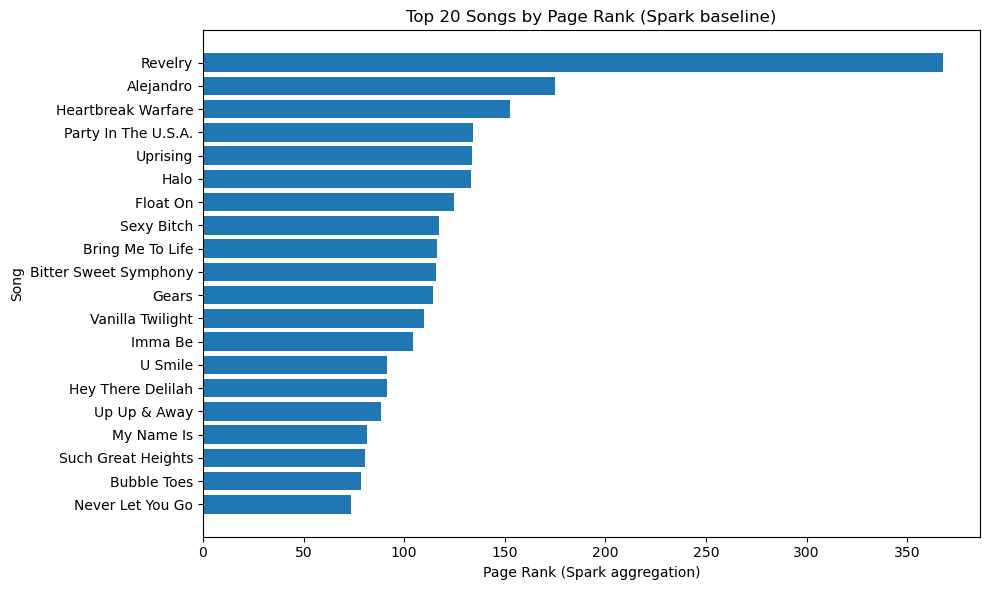

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Paths
# project_root = './../'
spark_outputs = "./../data_processed/spark_outputs"
csv_path = "./../data_processed/spark_outputs/song_pagerank_top1000.csv/part-00000-13cfa4c8-114a-4d3d-b084-0d04825af1c1-c000.csv"


print("Reading:", csv_path)
df = pd.read_csv(csv_path)
print(df.head())

# Use total_playcount as the popularity score
TOP_N = 20
topn = df.sort_values("pagerank", ascending=False).head(TOP_N)

plt.figure(figsize=(10, 6))
plt.barh(topn["name"][::-1], topn["pagerank"][::-1])
plt.xlabel("Page Rank (Spark aggregation)")
plt.ylabel("Song")
plt.title(f"Top {TOP_N} Songs by Page Rank (Spark baseline)")
plt.tight_layout()

# fig_dir =  "./figures"
# fig_dir.mkdir(exist_ok=True)
out_path = "./figures/song_pagerank_topn.png"   # keep this filename for the report
plt.savefig(out_path, dpi=300, bbox_inches="tight")

print("Saved figure to:", out_path)

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Paths
# project_root = Path("..").resolve()
# sample_dir = project_root / "data_processed" / "sample"
# spark_outputs = project_root / "data_processed" / "spark_outputs"

history_path = "./../data_processed/sample/user_listening_history_sample.csv"
pop_path = "./../data_processed/spark_outputs/song_popularity_top1000.csv/part-00000-91ba423c-7e8b-4f6c-9565-2812b3d8b6eb-c000.csv"

print("Reading history from:", history_path)
print("Reading popularity from:", pop_path)

history = pd.read_csv(history_path)
pop = pd.read_csv(pop_path)

print("History shape:", history.shape)
print("Popularity shape:", pop.shape)

# Choose a sample user (most active in the sample)
user_counts = history["user_id"].value_counts()
sample_user = user_counts.index[0]
print("\nSample user:", sample_user)
print("Tracks listened by this user (in sample):", user_counts.iloc[0])

# Tracks this user has already listened to
user_tracks = set(history.loc[history["user_id"] == sample_user, "track_id"])

# Candidate songs = popular songs the user has NOT listened to
candidates = pop[~pop["track_id"].isin(user_tracks)].copy()
# print(candidates)

# Rank by total_playcount
candidates = candidates.sort_values("total_playcount", ascending=False)

TOP_K = 10
topk = candidates.head(TOP_K).copy()
topk.insert(0, "rank", range(1, TOP_K + 1))

topk_display = topk[["rank", "name", "artist", "total_playcount"]]
topk_display

Reading history from: ./../data_processed/sample/user_listening_history_sample.csv
Reading popularity from: ./../data_processed/spark_outputs/song_popularity_top1000.csv/part-00000-91ba423c-7e8b-4f6c-9565-2812b3d8b6eb-c000.csv
History shape: (49172, 3)
Popularity shape: (1000, 23)

Sample user: db6a78c78c9239aba33861dae7611a6893fb27d5
Tracks listened by this user (in sample): 211


,rank,name,artist,total_playcount
4,1,Bring Me To Life,Katherine Jenkins,91448
5,2,Heartbreak Warfare,John Mayer,87745
6,3,Uprising,Sabaton,87050
7,4,Float On,Modest Mouse,85079
9,5,Bitter Sweet Symphony,The Verve,76893
10,6,Sexy Bitch,David Guetta,72259
11,7,Hey There Delilah,Plain White T's,66852
12,8,Vanilla Twilight,Owl City,63937
13,9,Imma Be,Black Eyed Peas,62438
14,10,U Smile,Justin Bieber,61568


Saved Top-K sample figure to: ./figures/topk_sample.png


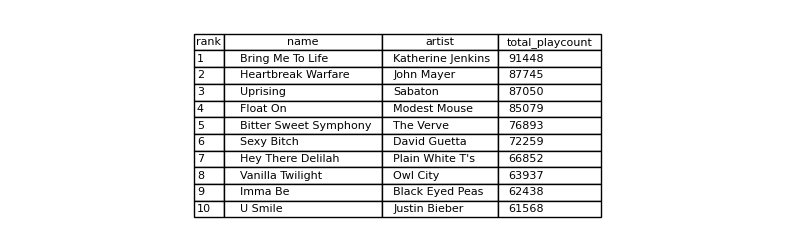

In [28]:
# Use matplotlib to render the Top-K table as a PNG figure
fig, ax = plt.subplots(figsize=(10, 3))
ax.axis("off")

table = ax.table(
    cellText=topk_display.values,
    colLabels=topk_display.columns,
    cellLoc="left",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(8)
table.auto_set_column_width(col=list(range(len(topk_display.columns))))

# fig_dir = project_root / "figures"
# fig_dir.mkdir(exist_ok=True)
out_path = "./figures/topk_sample.png"

plt.savefig(out_path, dpi=300, bbox_inches="tight")
print("Saved Top-K sample figure to:", out_path)
